In [26]:
# Basic imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             precision_recall_curve, auc)

# Data path
DATA_PATH = "/content/testing_dataset.csv"

# Load data
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (8698, 32)


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,13,-1,1,-1,1,-1,-1,0,0,1,...,-1,1,1,-1,-1,-1,1,0,1,-1
1,37,1,0,1,1,1,-1,-1,1,-1,...,-1,-1,-1,-1,0,-1,1,0,1,-1
2,38,1,0,1,1,1,-1,-1,-1,1,...,-1,1,-1,-1,0,-1,1,0,1,-1
3,43,1,-1,1,1,1,-1,-1,-1,1,...,-1,1,-1,-1,1,-1,1,-1,-1,-1
4,44,1,-1,1,1,1,-1,0,0,1,...,-1,1,1,-1,-1,-1,1,0,-1,-1


In [27]:
# Map labels -1 -> 0, 1 -> 1
label_col = "Result"
if "index" in df.columns:
    df = df.drop(columns=["index"])

# Drop rows with NaN in the label column
df = df.dropna(subset=[label_col])

df[label_col] = df[label_col].replace(-1, 0).astype(int)

# Split features & labels
X = df.drop(columns=[label_col])
y = df[label_col]

print("Label distribution:\n", y.value_counts())

Label distribution:
 Result
0    4349
1    4349
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Baseline Accuracy: 0.9729885057471265

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       870
           1       0.97      0.97      0.97       870

    accuracy                           0.97      1740
   macro avg       0.97      0.97      0.97      1740
weighted avg       0.97      0.97      0.97      1740



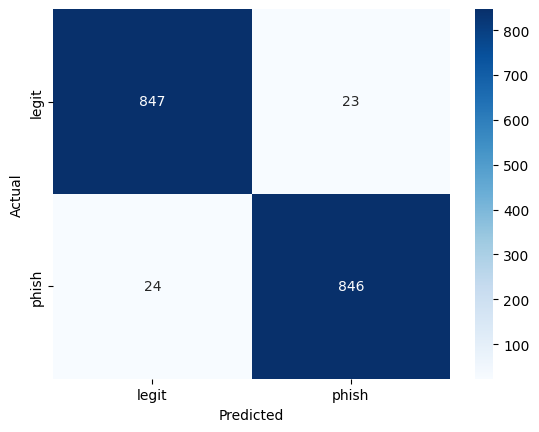

['/content/fake_site_rf_baseline.pkl']

In [29]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)

# Default predictions (threshold 0.5)
y_pred = rf.predict(X_test_s)

# Accuracy calculation **(This is where accuracy is calculated)**
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['legit','phish'], yticklabels=['legit','phish'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model & scaler
joblib.dump({"scaler":scaler,"model":rf,"features":X.columns.tolist()}, "/content/fake_site_rf_baseline.pkl")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   3.3s
[CV] END max_depth=10, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimators=40

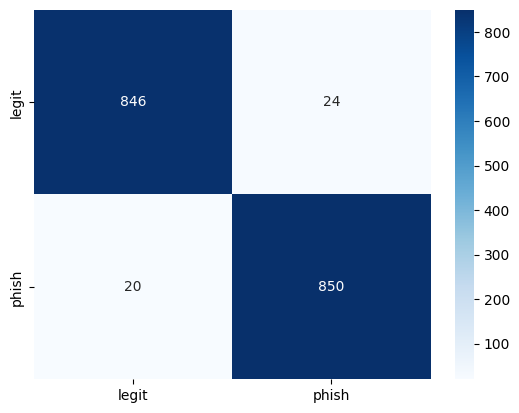

['/content/fake_site_rf_best.pkl']

In [30]:
param_dist = {
    "n_estimators": [100,200,400],
    "max_depth": [None,10,20,40],
    "min_samples_leaf": [1,2,4],
    "min_samples_split": [2,5,10],
    "max_features": ["sqrt","log2",0.5]
}

rs = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=12,
    scoring='f1',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)
rs.fit(X_train_s, y_train)
best_rf = rs.best_estimator_
print("Best RF params:", rs.best_params_)

# Evaluate best model
y_pred_best = best_rf.predict(X_test_s)
print("Accuracy (Best RF, threshold 0.5):", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['legit','phish'], yticklabels=['legit','phish'])
plt.show()

# Save best RF
joblib.dump({"scaler":scaler,"model":best_rf,"features":X.columns.tolist()}, "/content/fake_site_rf_best.pkl")


PR AUC: 0.9976242713835263


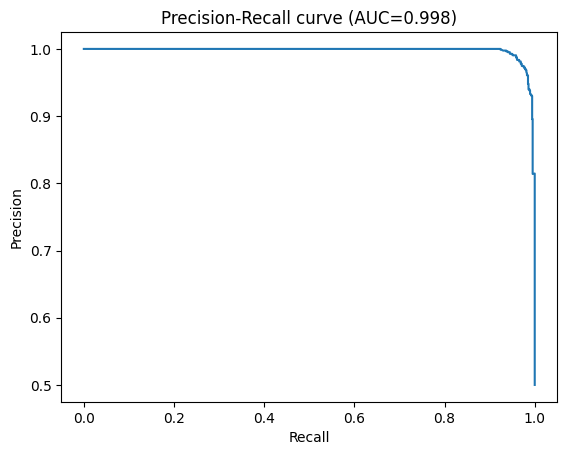

Threshold for recall>=0.9: 0.8649 with precision=1.000


In [31]:
probs = best_rf.predict_proba(X_test_s)[:,1]
prec, rec, thr = precision_recall_curve(y_test, probs)
pr_auc = auc(rec, prec)
print("PR AUC:", pr_auc)

# Plot PR curve
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AUC={pr_auc:.3f})")
plt.show()

# Choose threshold for desired recall
desired_recall = 0.9
idx = np.where(rec >= desired_recall)[0]
if len(idx) > 0:
    chosen = idx[-1]
    threshold = thr[chosen] if chosen < len(thr) else 0.5
    print(f"Threshold for recall>={desired_recall}: {threshold:.4f} with precision={prec[chosen]:.3f}")
else:
    threshold = 0.5
    print("Desired recall not achievable, using default threshold 0.5")


Accuracy (Threshold-adjusted): 0.95

Classification Report (Threshold-adjusted):
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       870
           1       1.00      0.90      0.95       870

    accuracy                           0.95      1740
   macro avg       0.95      0.95      0.95      1740
weighted avg       0.95      0.95      0.95      1740



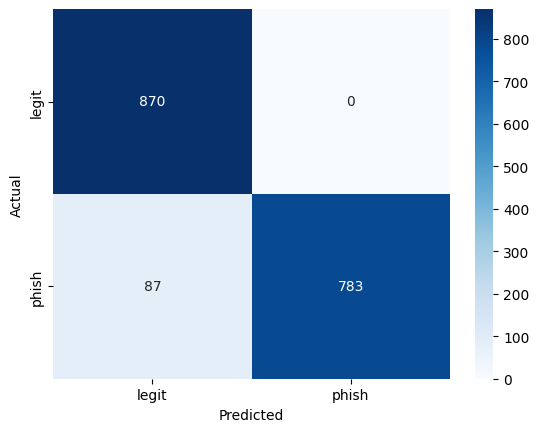

In [32]:
def predict_with_threshold(model, X, threshold=0.5):
    probs = model.predict_proba(X)[:,1]
    return (probs >= threshold).astype(int), probs

y_pred_thresh, _ = predict_with_threshold(best_rf, X_test_s, threshold)

# Final metrics
print("Accuracy (Threshold-adjusted):", accuracy_score(y_test, y_pred_thresh))
print("\nClassification Report (Threshold-adjusted):\n", classification_report(y_test, y_pred_thresh, zero_division=0))

cm = confusion_matrix(y_test, y_pred_thresh)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['legit','phish'], yticklabels=['legit','phish'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(best_rf, X, y, cv=cv, scoring='f1', n_jobs=-1)
acc_scores = cross_val_score(best_rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("CV F1 mean/std:", f1_scores.mean(), f1_scores.std())
print("CV Accuracy mean/std:", acc_scores.mean(), acc_scores.std())


CV F1 mean/std: 0.9733065415748333 0.004664683929385694
CV Accuracy mean/std: 0.973097301263112 0.004773472062264784


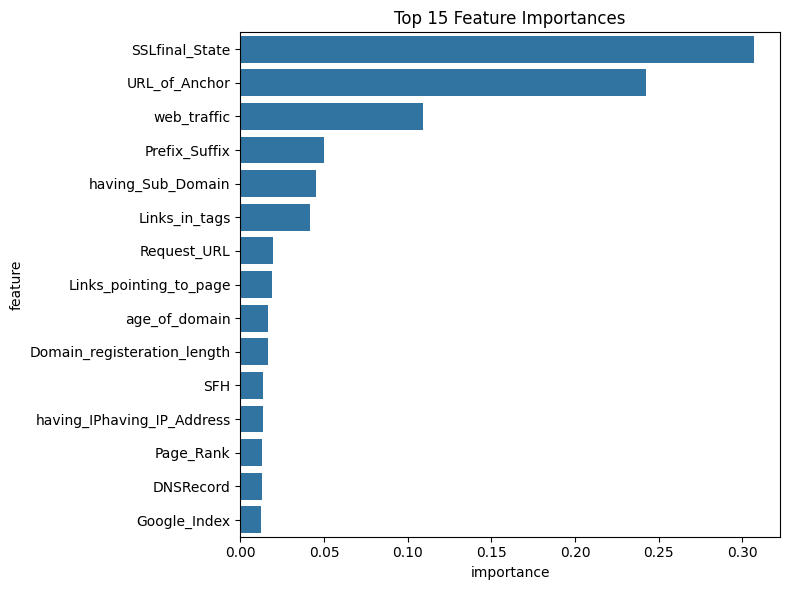

In [34]:
feat_names = X.columns.tolist()
importances = best_rf.feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

# Plot top 15
plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=imp_df.head(15))
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


In [35]:
joblib.dump({"scaler":scaler, "model":best_rf, "features":feat_names, "threshold": threshold}, "/content/fake_site_final.pkl")
print("Final model saved with threshold:", threshold)


Final model saved with threshold: 0.864939024390244
